In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco_Cusomer_Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.columns = df.columns.str.lower()

df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

### Observation

The column names were reviewed and converted to lowercase to maintain a consistent and standardized naming convention throughout the analysis.

In [7]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

### Observation

The missing-value check shows that all 21 columns contain 0 missing values. Therefore, there are no null values that require treatment in the dataset.

In [8]:
df['totalcharges'].value_counts().head(10)

totalcharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [9]:
df['totalcharges'] = df['totalcharges'].replace(' ', np.nan)

In [10]:
df.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [11]:
df[df['totalcharges'].isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
df['totalcharges'] = df['totalcharges'].fillna(0)

In [13]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'])

In [14]:
df['totalcharges'].dtype

dtype('float64')

In [15]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

### Observation

- Initially, the totalcharges column was stored as a string and contained 11 blank values. Further investigation showed that these records had a tenure value of 0. Since these records represent customers with no recorded tenure, the blank totalcharges values were treated as 0 rather than removing the records.

- The totalcharges column was then converted from string to numeric format to make it suitable for statistical analysis and visualization.

- After treatment, there were no missing values remaining in the dataset.

In [16]:
df.duplicated().sum()

np.int64(0)

### Observation

The duplicate-value check shows that there are 0 duplicate records in the dataset. Therefore, no duplicate rows were removed, and all 7,043 records are unique based on the complete row values.

In [17]:
df[['tenure', 'monthlycharges', 'totalcharges']].describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [18]:
Q1 = df[['tenure', 'monthlycharges', 'totalcharges']].quantile(0.25)
Q3 = df[['tenure', 'monthlycharges', 'totalcharges']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:")
print(lower_bound)

print("\nUpper Bound:")
print(upper_bound)

Lower Bound:
tenure             -60.000
monthlycharges     -46.025
totalcharges     -4683.525
dtype: float64

Upper Bound:
tenure             124.000
monthlycharges     171.375
totalcharges      8868.675
dtype: float64


### Why IQR Method Was Used

The IQR method was selected because it is a simple and robust method for detecting extreme values in numerical data. It identifies observations that fall below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.

In [21]:
outlier_counts = {}

for col in ['tenure', 'monthlycharges', 'totalcharges']:
    outliers = df[(df[col] < lower_bound[col]) | (df[col] > upper_bound[col])]
    outlier_counts[col] = len(outliers)

outlier_counts

{'tenure': 0, 'monthlycharges': 0, 'totalcharges': 0}

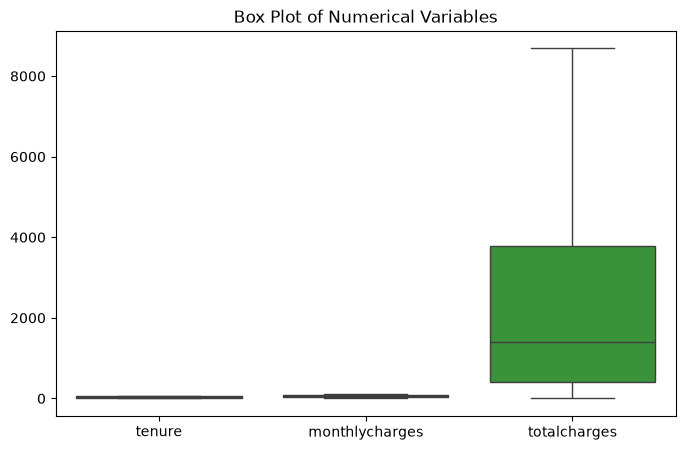

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['tenure', 'monthlycharges', 'totalcharges']])
plt.title('Box Plot of Numerical Variables')
plt.show()

### Observation

- The IQR method was used to detect potential outliers in the numerical variables tenure, monthlycharges, and totalcharges.

- The analysis shows that there are 0 outliers in all three variables. Therefore, no outlier records were removed from the dataset.

### Why This Plot Was Used

A box plot was used because it provides a visual summary of the distribution of numerical variables and helps identify potential outliers using the range between the quartiles.

In [23]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [24]:
df['churn'].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

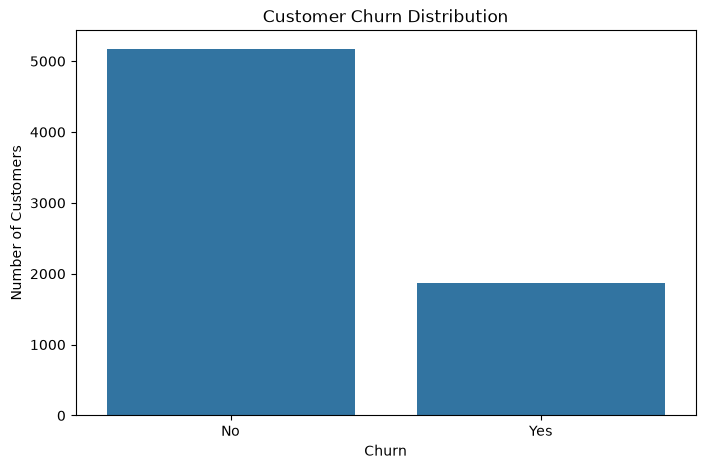

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to visually compare the number of customers in each churn category. It helps identify whether the target variable is balanced or imbalanced and makes the difference between the two classes easy to interpret.

### Observation

- The churn distribution shows that 5,174 customers (73.46%) did not churn, while 1,869 customers (26.54%) churned.

- This indicates that the target variable is moderately imbalanced, as the number of customers who did not churn is considerably higher than the number of customers who churned.

- However, both classes have a sufficient number of observations, so no class-balancing treatment was applied for this exploratory data analysis.

In [26]:
df[['tenure', 'monthlycharges', 'totalcharges']].describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


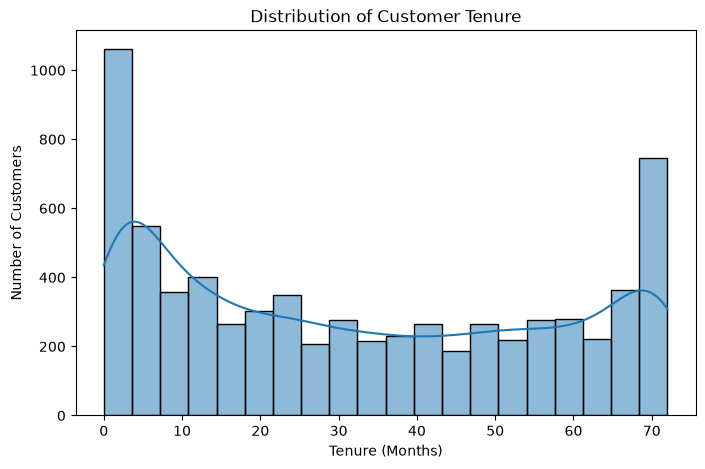

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df['tenure'], bins=20, kde=True)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A histogram was used to understand the distribution of customer tenure and identify the range in which most customers have been associated with the company.

### Observation

- The customer tenure ranges from 0 to 72 months.

- The distribution shows a high concentration of customers with very low tenure, particularly during the first few months. The number of customers is more evenly distributed across the middle tenure range, with another noticeable increase among customers with tenure close to 70–72 months.

- This indicates that the dataset contains both newer customers and long-term customers.

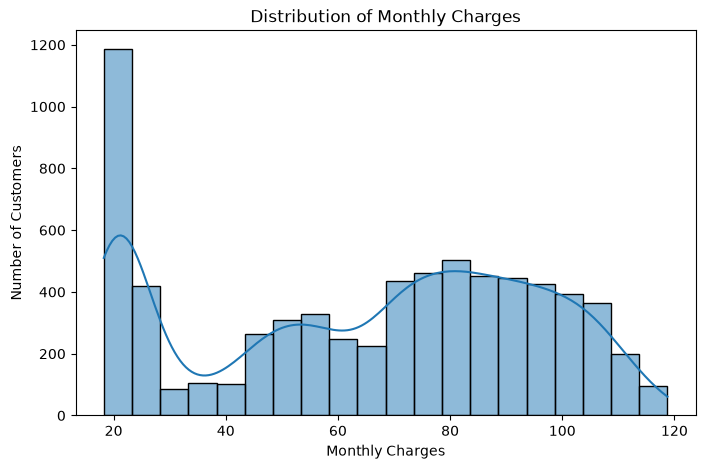

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df['monthlycharges'], bins=20, kde=True)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A histogram was used to understand the distribution of customers' monthly charges and identify the charge ranges where customers are most concentrated.

### Observation

- The monthly charges range from approximately 18 to 119.

- The distribution shows a high concentration of customers with lower monthly charges, particularly around 18–25. There is also a substantial concentration of customers with monthly charges between approximately 70 and 110.

- This indicates that customers have varying monthly charges, with many customers concentrated in both the lower and higher charge ranges.

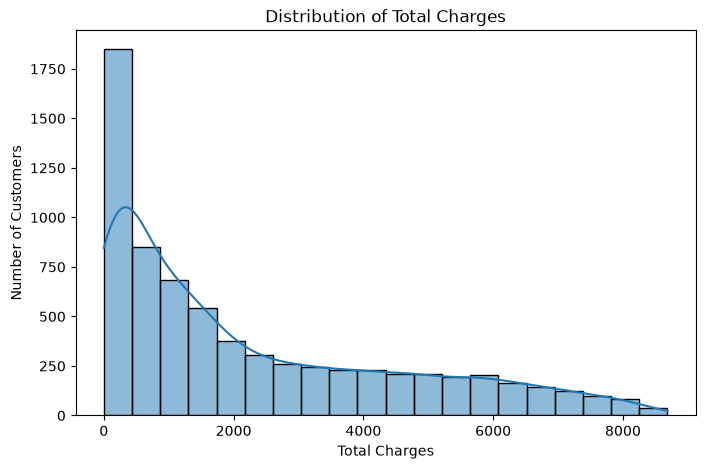

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df['totalcharges'], bins=20, kde=True)

plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A histogram was used to understand the distribution of customers' total charges and identify the ranges where total charges are most concentrated.m

### Observation

- The total charges range from 0 to approximately 8,685.

- The distribution is strongly right-skewed, with a large concentration of customers having relatively low total charges. The number of customers gradually decreases as total charges increase.

- This pattern is expected because total charges are influenced by both the customer's monthly charges and their tenure with the company.

In [31]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

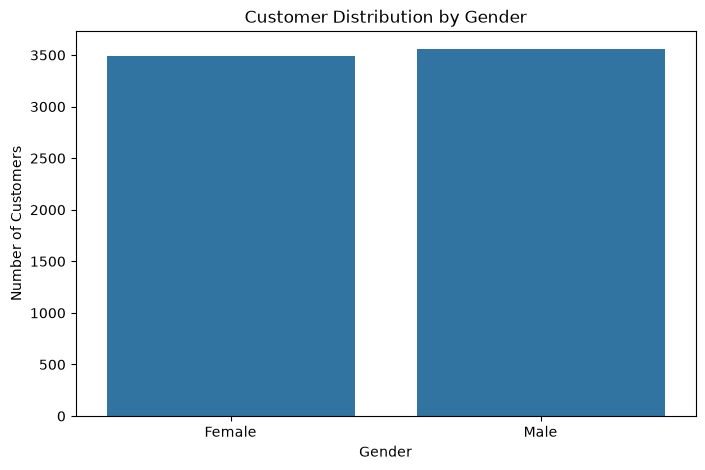

In [32]:
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare the number of customers in each gender category and understand the gender distribution of the customer base.

### Observation

- The dataset contains 3,555 male customers and 3,488 female customers.

- The distribution is almost balanced between male and female customers, with only a small difference in the number of customers in the two categories.

- Therefore, gender is fairly evenly represented in the dataset.

In [34]:
df['partner'].value_counts()

partner
No     3641
Yes    3402
Name: count, dtype: int64

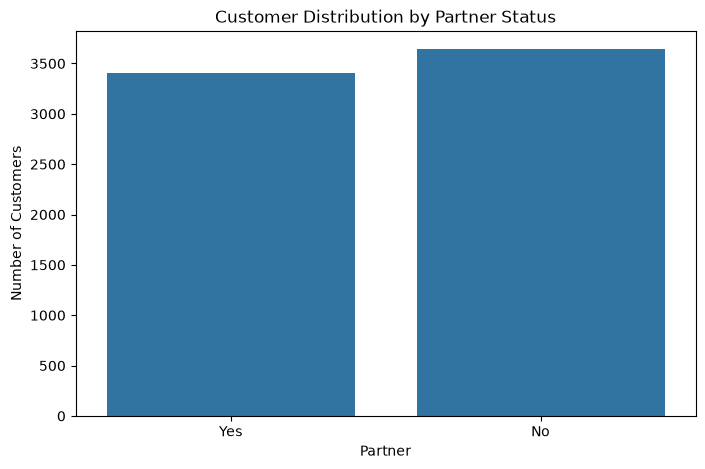

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(x='partner', data=df)

plt.title('Customer Distribution by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers who have a partner with those who do not have a partner and understand the distribution of partner status in the dataset.

### Observation

- The dataset contains 3,641 customers who do not have a partner and 3,402 customers who have a partner.

- The distribution is relatively balanced, although customers without a partner are slightly more numerous than customers with a partner.

In [36]:
df['dependents'].value_counts()

dependents
No     4933
Yes    2110
Name: count, dtype: int64

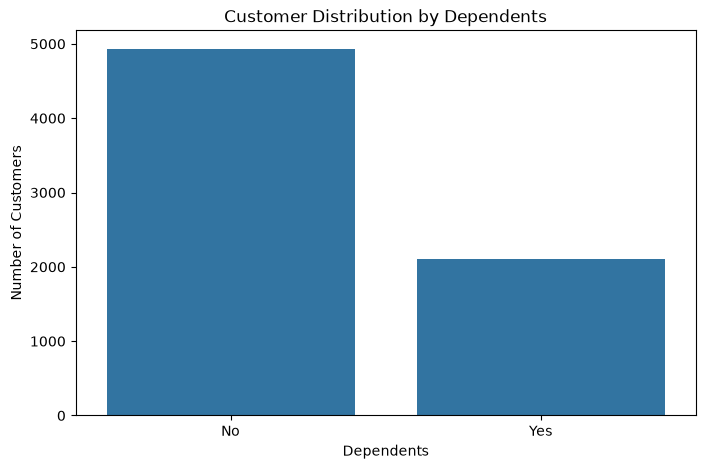

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(x='dependents', data=df)

plt.title('Customer Distribution by Dependents')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers with and without dependents and understand the distribution of dependents among the customer base.

### Observation

- The dataset contains 4,933 customers without dependents and 2,110 customers with dependents.

- The majority of customers do not have dependents, while a smaller proportion of customers have dependents.

In [38]:
df['phoneservice'].value_counts()

phoneservice
Yes    6361
No      682
Name: count, dtype: int64

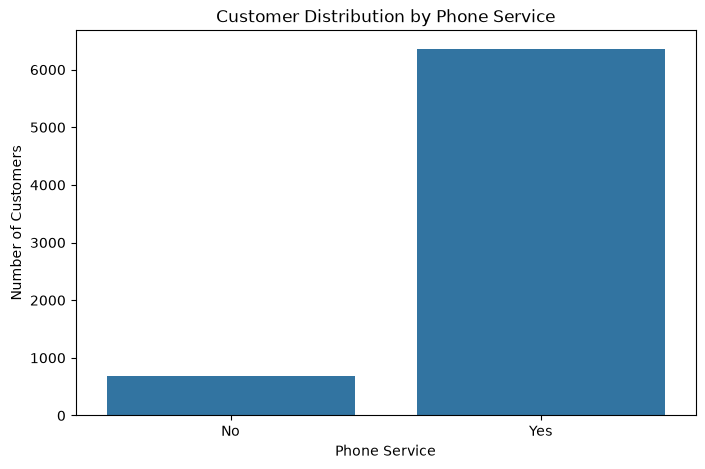

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='phoneservice', data=df)

plt.title('Customer Distribution by Phone Service')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers who have phone service with those who do not have phone service and understand the distribution of phone service among customers.

### Observation

- The dataset contains 6,361 customers with phone service and 682 customers without phone service.

- The majority of customers have phone service, while only a small proportion of customers do not have phone service.

In [28]:
df['multiplelines'].value_counts()

multiplelines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

### Why This Plot Was Used

A count plot was used to compare the different multiple-line service categories and understand how customers are distributed across these categories.

### Observation

- The dataset contains 3,390 customers with a single phone line, 2,971 customers with multiple lines, and 682 customers without phone service.

- Customers with a single phone line form the largest category, followed by customers with multiple lines. Customers without phone service form the smallest category.

In [29]:
df['internetservice'].value_counts()

internetservice
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

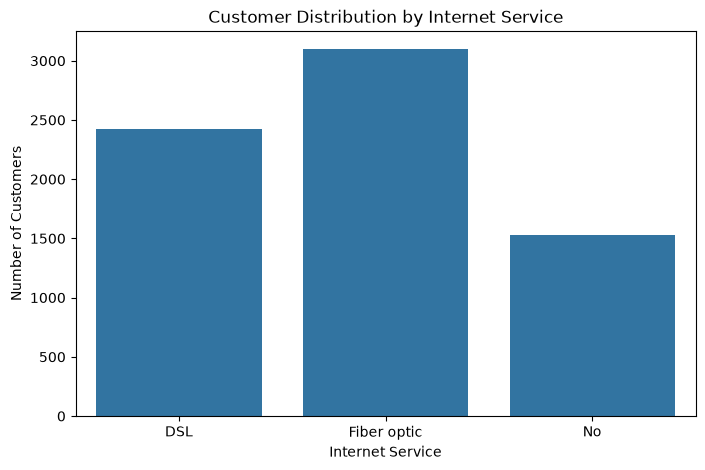

In [42]:
plt.figure(figsize=(8, 5))
sns.countplot(x='internetservice', data=df)

plt.title('Customer Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare the different internet service categories and understand how customers are distributed across the available internet service types.

### Observation

- The dataset contains 3,096 customers with Fiber optic service, 2,421 customers with DSL service, and 1,526 customers without internet service.

- Fiber optic is the most common internet service type, followed by DSL. Customers without internet service form the smallest category.m

In [43]:
df['onlinesecurity'].value_counts()

onlinesecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

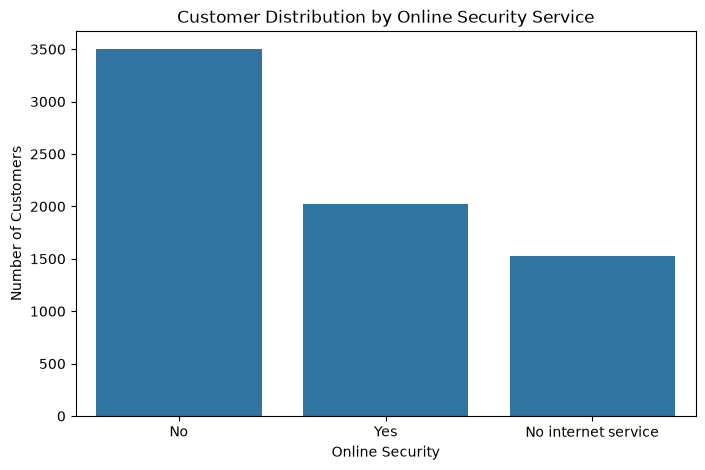

In [44]:
plt.figure(figsize=(8, 5))
sns.countplot(x='onlinesecurity', data=df)

plt.title('Customer Distribution by Online Security Service')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers across the different online security service categories and understand the adoption of online security services.m

### Observation

- The dataset contains 3,498 customers who do not have online security, 2,019 customers who have online security, and 1,526 customers with no internet service.

- Customers without online security form the largest category, while customers with no internet service form the smallest category.

In [46]:
df['onlinebackup'].value_counts()

onlinebackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

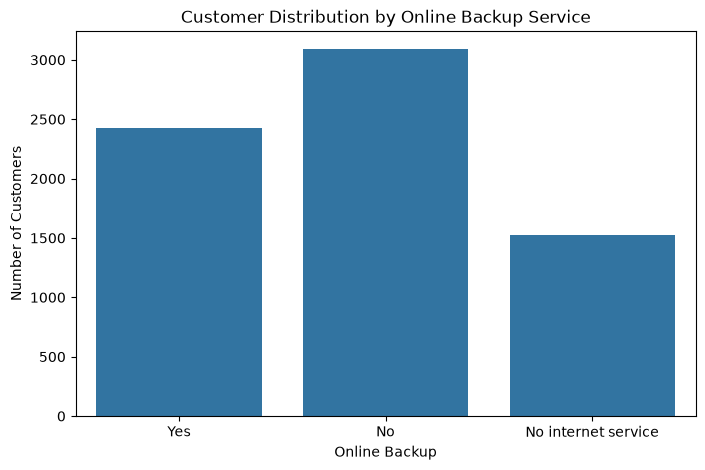

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(x='onlinebackup', data=df)

plt.title('Customer Distribution by Online Backup Service')
plt.xlabel('Online Backup')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers across the different online backup service categories and understand the adoption of online backup services.

### Observation

- The dataset contains 3,088 customers who do not have online backup, 2,429 customers who have online backup, and 1,526 customers with no internet service.

- Customers without online backup form the largest category, followed by customers with online backup. Customers with no internet service form the smallest category.

In [30]:
df['deviceprotection'].value_counts()

deviceprotection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

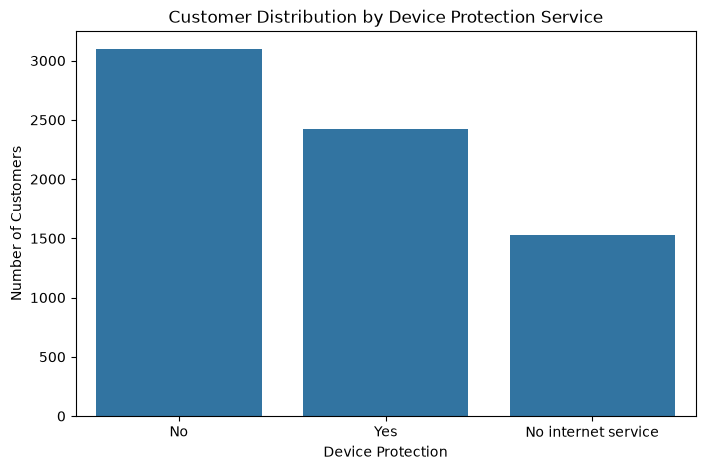

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(x='deviceprotection', data=df)

plt.title('Customer Distribution by Device Protection Service')
plt.xlabel('Device Protection')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers across the different device protection service categories and understand the adoption of device protection services.

### Observation

- The dataset contains 3,095 customers who do not have device protection, 2,422 customers who have device protection, and 1,526 customers with no internet service.

- Customers without device protection form the largest category, followed by customers with device protection. Customers with no internet service form the smallest category.

In [32]:
df['techsupport'].value_counts()

techsupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

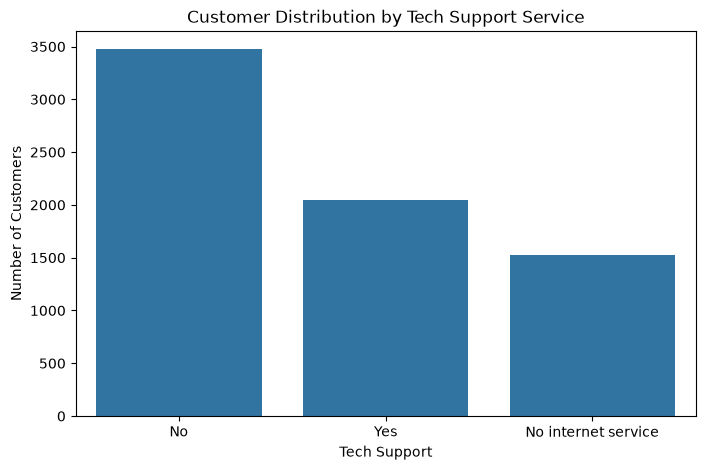

In [33]:
plt.figure(figsize=(8, 5))
sns.countplot(x='techsupport', data=df)

plt.title('Customer Distribution by Tech Support Service')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers across the different technical support service categories and understand the adoption of tech support services.

### Observation

- The dataset contains 3,473 customers who do not have tech support, 2,044 customers who have tech support, and 1,526 customers with no internet service.

- Customers without tech support form the largest category, followed by customers with tech support. Customers with no internet service form the smallest category.

In [34]:
df['streamingtv'].value_counts()

streamingtv
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

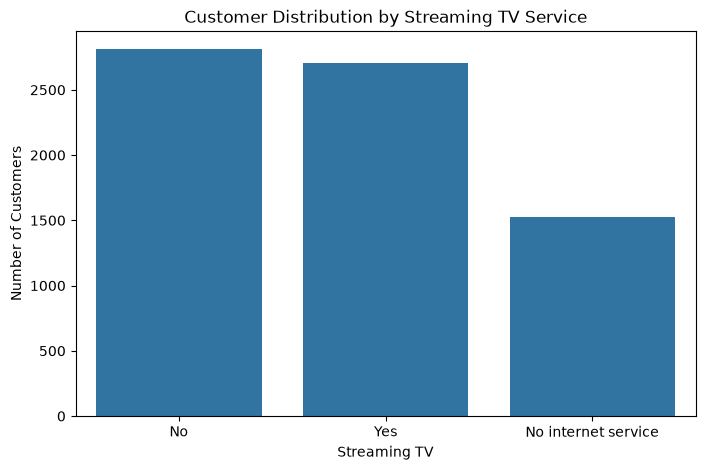

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(x='streamingtv', data=df)

plt.title('Customer Distribution by Streaming TV Service')
plt.xlabel('Streaming TV')
plt.ylabel('Number of Customers')

plt.show()

### Why This Plot Was Used

A count plot was used to compare customers across the different streaming TV service categories and understand the adoption of streaming TV services.

### Observation
- The dataset contains 2,810 customers who do not have streaming TV, 2,707 customers who have streaming TV, and 1,526 customers with no internet service.

- Customers without streaming TV form the largest category, followed by customers with streaming TV. Customers with no internet service form the smallest category.

In [36]:
df['streamingmovies'].value_counts()

streamingmovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

### Observation
- The dataset contains 2,785 customers who do not have streaming movies, 2,732 customers who have streaming movies, and 1,526 customers with no internet service.

- Customers without streaming movies form the largest category, followed closely by customers with streaming movies. Customers with no internet service form the smallest category.

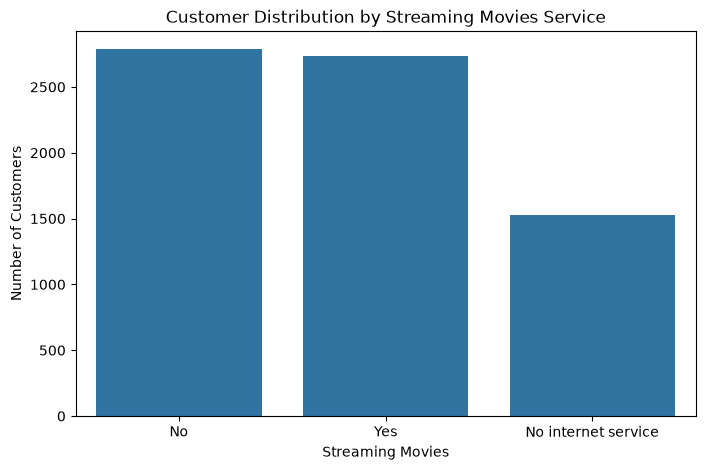

In [37]:
plt.figure(figsize=(8, 5))
sns.countplot(x='streamingmovies', data=df)
plt.title('Customer Distribution by Streaming Movies Service')
plt.xlabel('Streaming Movies')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot was used to compare customers across the different streaming movies service categories and understand the adoption of streaming movies services.

In [38]:
df['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

### Observation
- The dataset contains 3,875 customers with a month-to-month contract, 1,695 customers with a two-year contract, and 1,473 customers with a one-year contract.

- Month-to-month contracts are the most common, representing the largest customer group. Two-year contracts are the second most common, while one-year contracts form the smallest category.

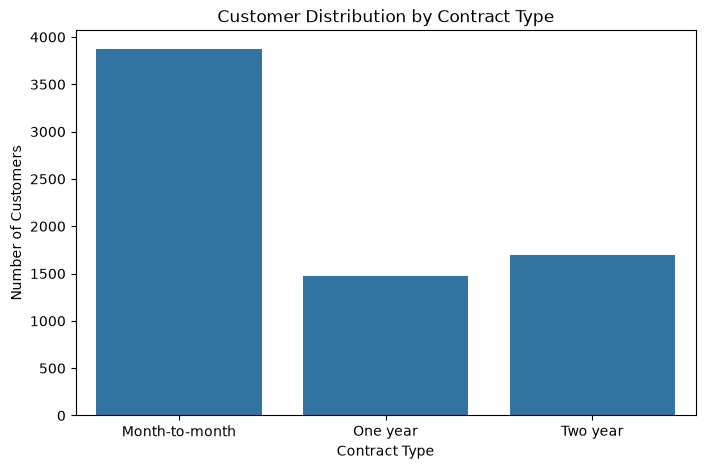

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='contract', data=df)
plt.title('Customer Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot was used to compare the number of customers across different contract types and understand which contract options are most common among customers.

In [40]:
df['paperlessbilling'].value_counts()

paperlessbilling
Yes    4171
No     2872
Name: count, dtype: int64

### Observation
- The dataset contains 4,171 customers who use paperless billing and 2,872 customers who do not use paperless billing.

- The majority of customers use paperless billing, while a smaller proportion of customers use other billing methods.

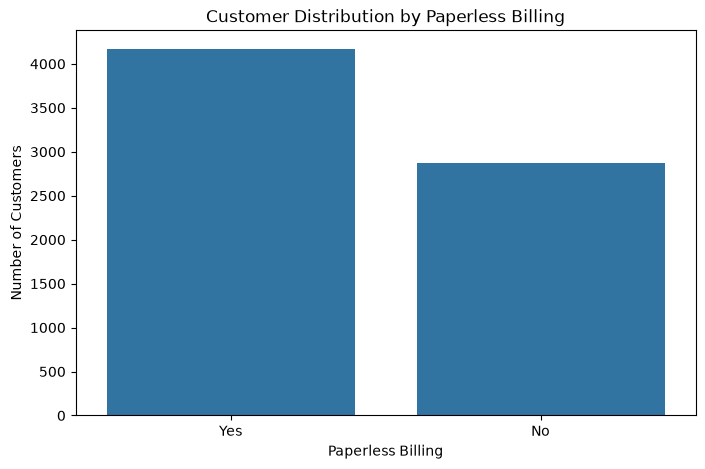

In [41]:
plt.figure(figsize=(8, 5))
sns.countplot(x='paperlessbilling', data=df)
plt.title('Customer Distribution by Paperless Billing')
plt.xlabel('Paperless Billing')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot was used to compare the number of customers who use paperless billing with those who do not and understand the billing preference of the customer base.

In [42]:
df['paymentmethod'].value_counts()

paymentmethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

### Observation
- The dataset contains 2,365 customers who use electronic check, 1,612 customers who use mailed check, 1,544 customers who use bank transfer (automatic), and 1,522 customers who use credit card (automatic).

- Electronic check is the most common payment method, while credit card (automatic) is the least common among the four payment methods.

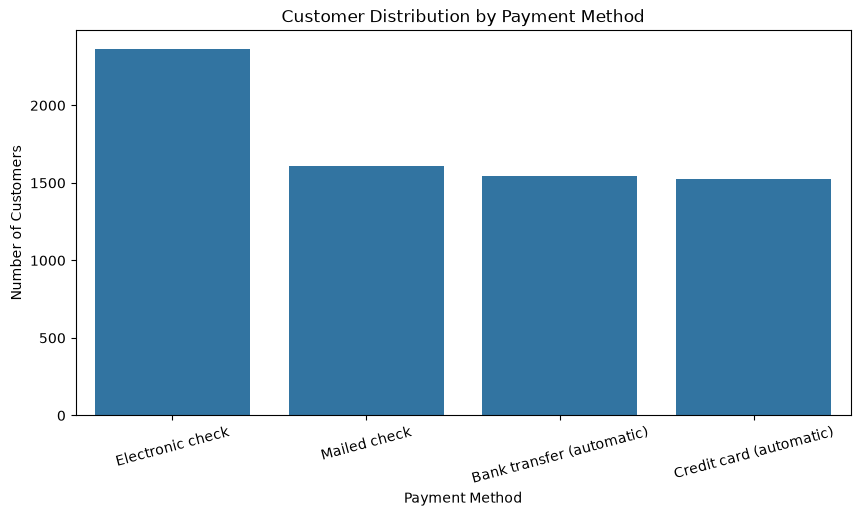

In [61]:
plt.figure(figsize=(10, 5))
sns.countplot(x='paymentmethod', data=df)
plt.title('Customer Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

### Why This Plot Was Used
A count plot was used to compare the number of customers using each payment method and understand the most and least common payment preferences.

In [43]:
pd.crosstab(df['contract'], df['churn'])

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


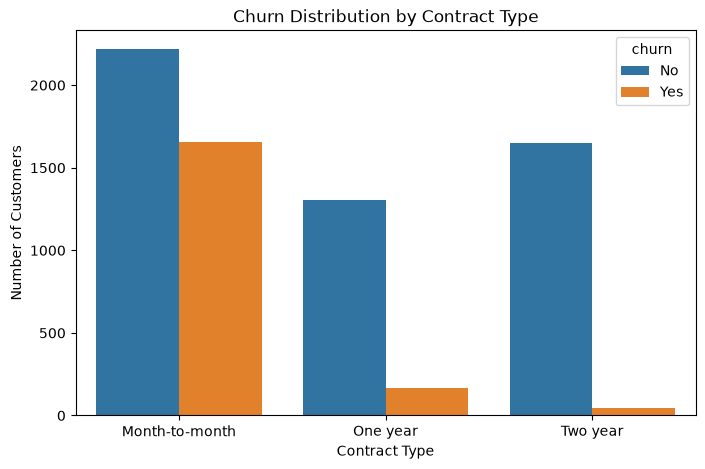

In [44]:
plt.figure(figsize=(8, 5))
sns.countplot(x='contract', hue='churn', data=df)
plt.title('Churn Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot with churn as the hue was used to compare churn and non-churn customers across different contract types. This helps identify whether customer churn varies depending on the type of contract.

### Observation
- The month-to-month contract has the highest number of churned customers, with 1,655 customers churning out of 3,875 customers.

- The one-year contract has 166 churned customers out of 1,473 customers, while the two-year contract has only 48 churned customers out of 1,695 customers.

- The churn rate is approximately 42.7% for month-to-month customers, 11.3% for one-year contract customers, and 2.8% for two-year contract customers.

- This indicates that customers with month-to-month contracts are considerably more likely to churn than customers with longer-term contracts.

In [64]:
pd.crosstab(df['internetservice'], df['churn'])

churn,No,Yes
internetservice,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


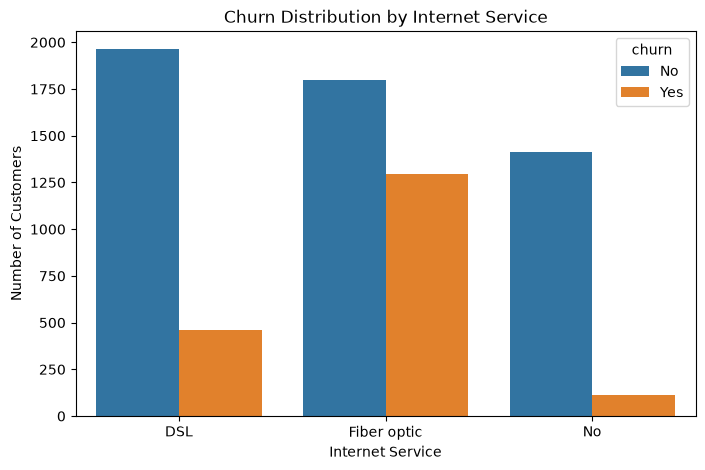

In [65]:
plt.figure(figsize=(8, 5))
sns.countplot(x='internetservice', hue='churn', data=df)
plt.title('Churn Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

### Observation
- Among customers with DSL service, 459 customers churned while 1,962 customers did not churn.

- Among customers with Fiber optic service, 1,297 customers churned while 1,799 customers did not churn.

- Among customers without internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 19.0% for DSL customers, 41.9% for Fiber optic customers, and 7.4% for customers without internet service.

- This indicates that Fiber optic customers have the highest churn rate among the three internet service groups.

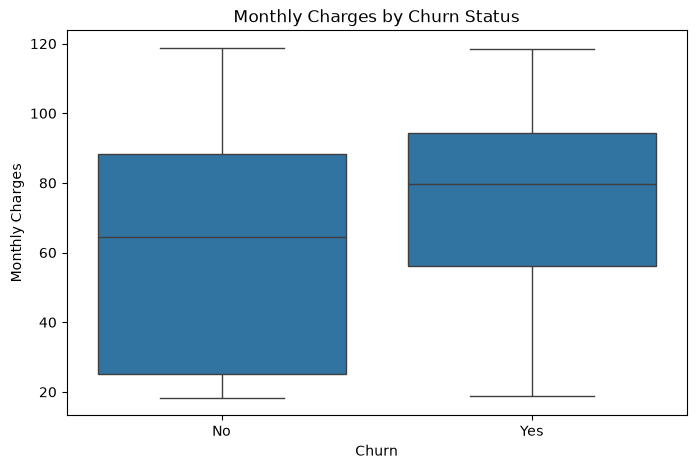

In [66]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn', y='monthlycharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Why This Plot Was Used
A box plot was used to compare the distribution of monthly charges between customers who churned and those who did not churn. It helps compare the median, spread, and overall range of monthly charges across the two churn groups.

### Observation
- The box plot shows that customers who churned generally have higher monthly charges than customers who did not churn.

- The median monthly charge for churned customers is higher than the median for customers who did not churn. The distribution also shows that churned customers are more concentrated in the higher monthly charge range.

- This suggests that higher monthly charges may be associated with a greater likelihood of customer churn.

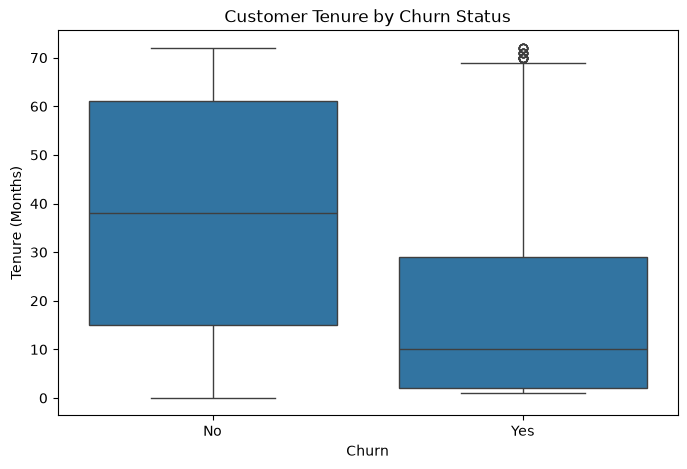

In [67]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn', y='tenure', data=df)
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

### Why This Plot Was Used
A box plot was used to compare the distribution of customer tenure between customers who churned and those who did not churn. It helps identify differences in the median tenure and overall spread between the two churn groups.

### Observation
- The box plot shows that customers who churned generally have shorter tenure than customers who did not churn.

- The median tenure of churned customers is considerably lower than the median tenure of customers who did not churn.

- This suggests that newer customers are more likely to churn, while customers with longer tenure tend to remain with the company.

In [68]:
pd.crosstab(df['paymentmethod'], df['churn'])

churn,No,Yes
paymentmethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


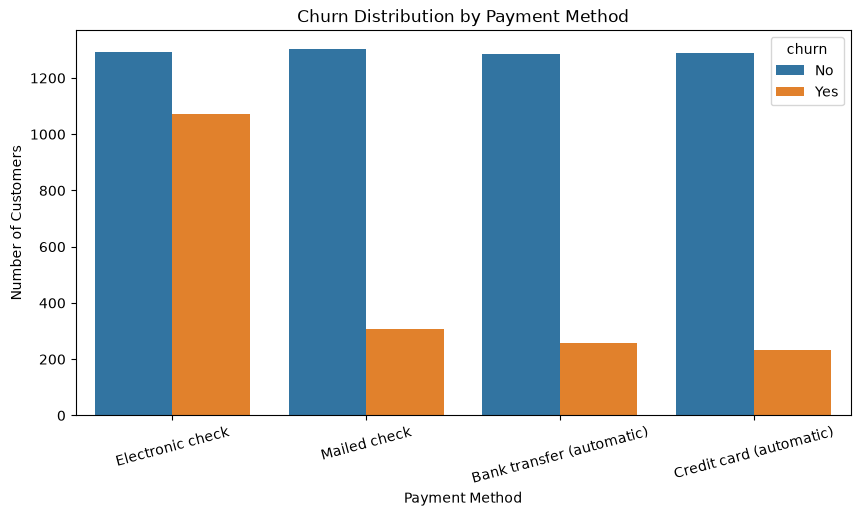

In [69]:
plt.figure(figsize=(10, 5))
sns.countplot(x='paymentmethod', hue='churn', data=df)
plt.title('Churn Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

### Why This Plot Was Used
A count plot with churn as the hue was used to compare churn and non-churn customers across different payment methods. This helps identify whether customer churn varies depending on the payment method used.

### Observation
- The electronic check payment method has the highest number of churned customers, with 1,071 customers churning out of 2,365 customers.

- The churn rates are approximately 45.3% for electronic check, 19.1% for mailed check, 16.7% for bank transfer (automatic), and 15.2% for credit card (automatic).

- Customers using electronic check have a considerably higher churn rate than customers using the other payment methods.

- This suggests that payment method may be associated with customer churn, with electronic check users showing the highest churn rate.

In [70]:
pd.crosstab(df['partner'], df['churn'])

churn,No,Yes
partner,,
No,2441,1200
Yes,2733,669


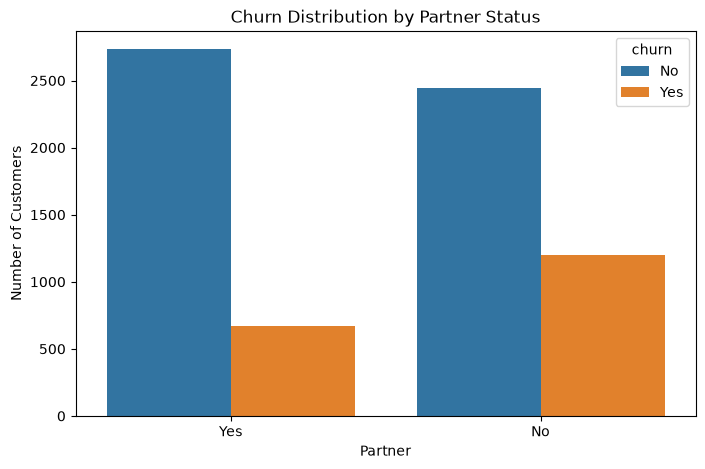

In [71]:
plt.figure(figsize=(8, 5))
sns.countplot(x='partner', hue='churn', data=df)
plt.title('Churn Distribution by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot with churn as the hue was used to compare churn and non-churn customers based on partner status. This helps identify whether having a partner is associated with differences in customer churn.

### Observation
- Among customers without a partner, 1,200 customers churned while 2,441 customers did not churn.

- Among customers with a partner, 669 customers churned while 2,733 customers did not churn.

- The churn rate is approximately 33.0% for customers without a partner and 19.7% for customers with a partner.

- This indicates that customers without a partner have a higher churn rate than customers with a partner.

In [73]:
pd.crosstab(df['dependents'], df['churn'])

churn,No,Yes
dependents,,
No,3390,1543
Yes,1784,326


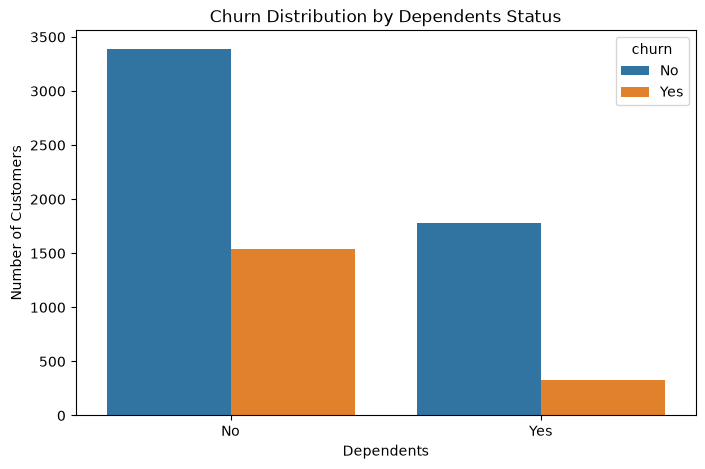

In [74]:
plt.figure(figsize=(8, 5))
sns.countplot(x='dependents', hue='churn', data=df)
plt.title('Churn Distribution by Dependents Status')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot with churn as the hue was used to compare churn and non-churn customers based on whether they have dependents. This helps identify whether having dependents is associated with differences in customer churn.

### Observation
- Among customers without dependents, 1,543 customers churned while 3,390 customers did not churn.

- Among customers with dependents, 326 customers churned while 1,784 customers did not churn.

- The churn rate is approximately 31.3% for customers without dependents and 15.4% for customers with dependents.

- This indicates that customers without dependents have a higher churn rate than customers with dependents.

In [75]:
pd.crosstab(df['onlinesecurity'], df['churn'])

churn,No,Yes
onlinesecurity,,
No,2037,1461
No internet service,1413,113
Yes,1724,295


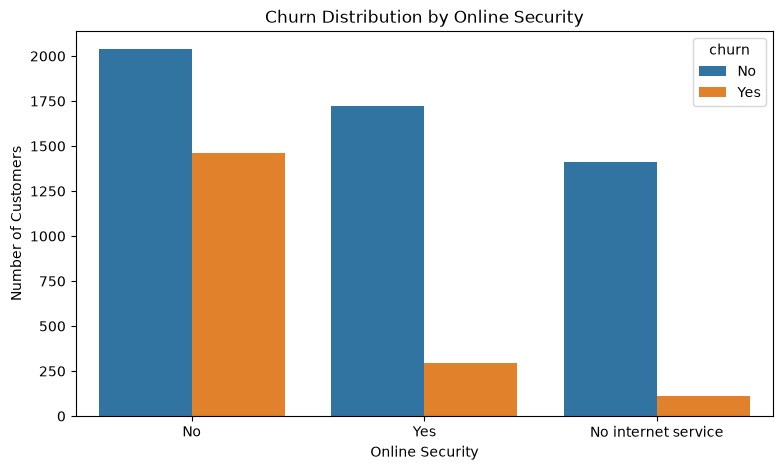

In [76]:
plt.figure(figsize=(9, 5))
sns.countplot(x='onlinesecurity', hue='churn', data=df)
plt.title('Churn Distribution by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used
A count plot with churn as the hue was used to compare churn and non-churn customers across online security service categories. This helps identify whether having online security is associated with differences in customer churn.

### Observation
- Among customers without online security, 1,461 customers churned while 2,037 customers did not churn.

- Among customers with online security, 295 customers churned while 1,724 customers did not churn.

- Among customers with no internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 41.8% for customers without online security, 14.6% for customers with online security, and 7.4% for customers with no internet service.

- This indicates that customers without online security have a considerably higher churn rate than customers with online security.

In [45]:
pd.crosstab(df['techsupport'], df['churn'])

churn,No,Yes
techsupport,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


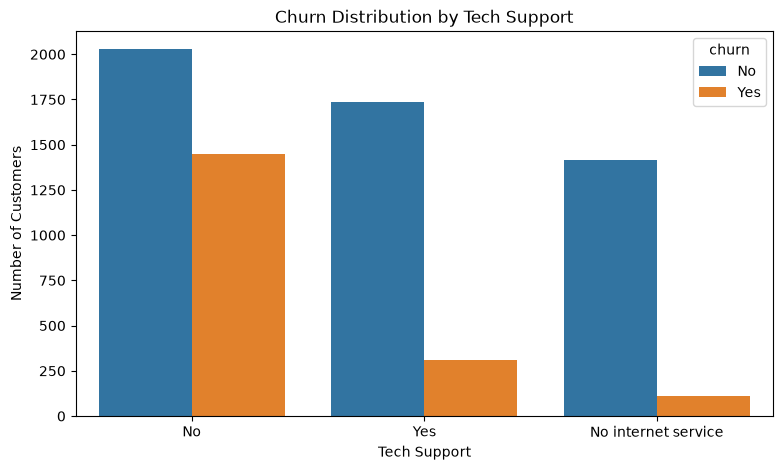

In [46]:
plt.figure(figsize=(9, 5))
sns.countplot(x='techsupport', hue='churn', data=df)
plt.title('Churn Distribution by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across different technical support service categories. This helps identify whether having technical support is associated with differences in customer churn.

### Observation

- Among customers without technical support, 1,446 customers churned while 2,027 customers did not churn.

- Among customers with technical support, 310 customers churned while 1,734 customers did not churn.

- Among customers with no internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 41.6% for customers without technical support, 15.2% for customers with technical support, and 7.4% for customers with no internet service.

- This indicates that customers without technical support have a considerably higher churn rate than customers with technical support.

In [47]:
pd.crosstab(df['onlinebackup'], df['churn'])

churn,No,Yes
onlinebackup,,
No,1855,1233
No internet service,1413,113
Yes,1906,523


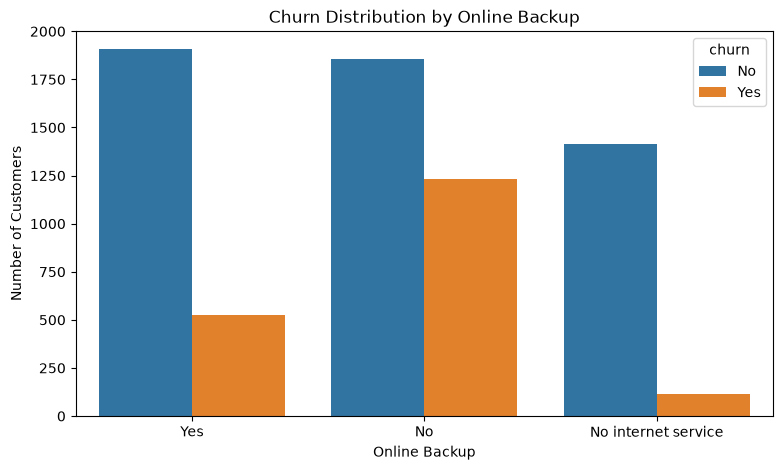

In [48]:
plt.figure(figsize=(9, 5))
sns.countplot(x='onlinebackup', hue='churn', data=df)
plt.title('Churn Distribution by Online Backup')
plt.xlabel('Online Backup')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across different online backup service categories. This helps identify whether having online backup is associated with differences in customer churn.

### Observation

- Among customers without online backup, 1,233 customers churned while 1,855 customers did not churn.

- Among customers with online backup, 523 customers churned while 1,906 customers did not churn.

- Among customers with no internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 40.0% for customers without online backup, 17.7% for customers with online backup, and 7.4% for customers with no internet service.

- This indicates that customers without online backup have a considerably higher churn rate than customers with online backup.m

In [49]:
pd.crosstab(df['deviceprotection'], df['churn'])

churn,No,Yes
deviceprotection,,
No,1884,1211
No internet service,1413,113
Yes,1877,545


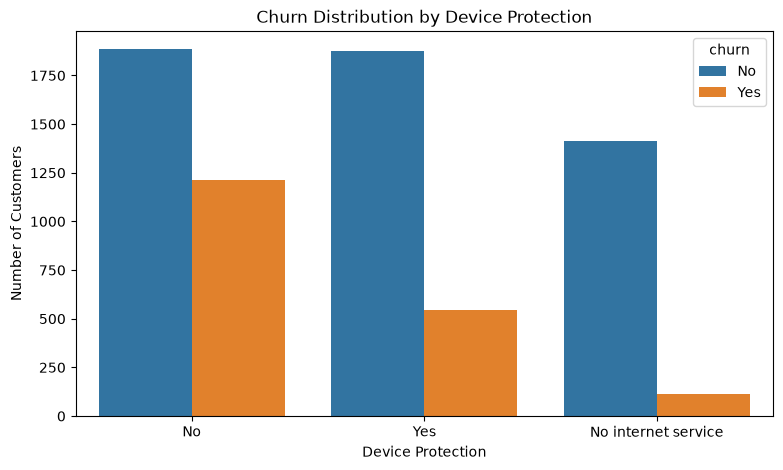

In [50]:
plt.figure(figsize=(9, 5))
sns.countplot(x='deviceprotection', hue='churn', data=df)
plt.title('Churn Distribution by Device Protection')
plt.xlabel('Device Protection')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across different device protection service categories. This helps identify whether having device protection is associated with differences in customer churn.

### Observation

- Among customers without device protection, 1,211 customers churned while 1,884 customers did not churn.

- Among customers with device protection, 545 customers churned while 1,877 customers did not churn.

- Among customers with no internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 39.1% for customers without device protection, 22.5% for customers with device protection, and 7.4% for customers with no internet service.

- This indicates that customers without device protection have a higher churn rate than customers with device protection.

In [51]:
pd.crosstab(df['streamingtv'], df['churn'])

churn,No,Yes
streamingtv,,
No,1868,942
No internet service,1413,113
Yes,1893,814


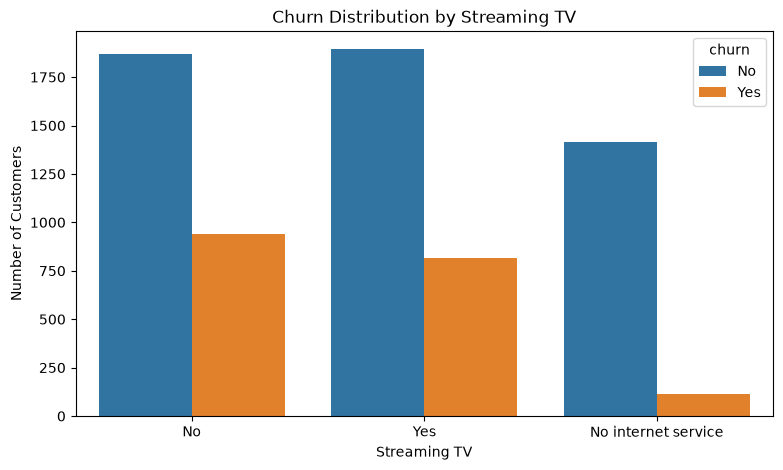

In [52]:
plt.figure(figsize=(9, 5))
sns.countplot(x='streamingtv', hue='churn', data=df)
plt.title('Churn Distribution by Streaming TV')
plt.xlabel('Streaming TV')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across different streaming TV service categories. This helps identify whether having streaming TV is associated with differences in customer churn.

### Observation

- Among customers without streaming TV, 942 customers churned while 1,868 customers did not churn.

- Among customers with streaming TV, 814 customers churned while 1,893 customers did not churn.

- Among customers with no internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 33.5% for customers without streaming TV, 23.1% for customers with streaming TV, and 7.4% for customers with no internet service.

- This indicates that customers without streaming TV have a higher churn rate than customers with streaming TV.

In [53]:
pd.crosstab(df['streamingmovies'], df['churn'])

churn,No,Yes
streamingmovies,,
No,1847,938
No internet service,1413,113
Yes,1914,818


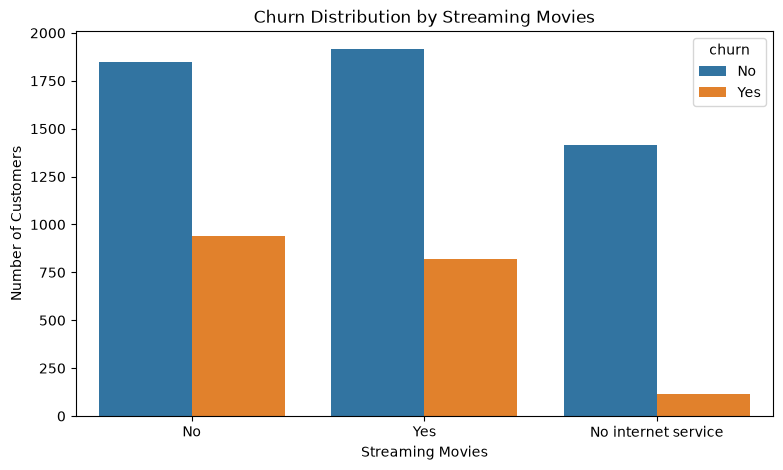

In [54]:
plt.figure(figsize=(9, 5))
sns.countplot(x='streamingmovies', hue='churn', data=df)
plt.title('Churn Distribution by Streaming Movies')
plt.xlabel('Streaming Movies')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across different streaming movies service categories. This helps identify whether having streaming movies is associated with differences in customer churn.

### Observation

- Among customers without streaming movies, 938 customers churned while 1,847 customers did not churn.

- Among customers with streaming movies, 818 customers churned while 1,914 customers did not churn.

- Among customers with no internet service, 113 customers churned while 1,413 customers did not churn.

- The churn rate is approximately 33.7% for customers without streaming movies, 29.9% for customers with streaming movies, and 7.4% for customers with no internet service.

- This indicates that customers without streaming movies have a slightly higher churn rate than customers with streaming movies.

In [55]:
pd.crosstab(df['paperlessbilling'], df['churn'])

churn,No,Yes
paperlessbilling,,
No,2403,469
Yes,2771,1400


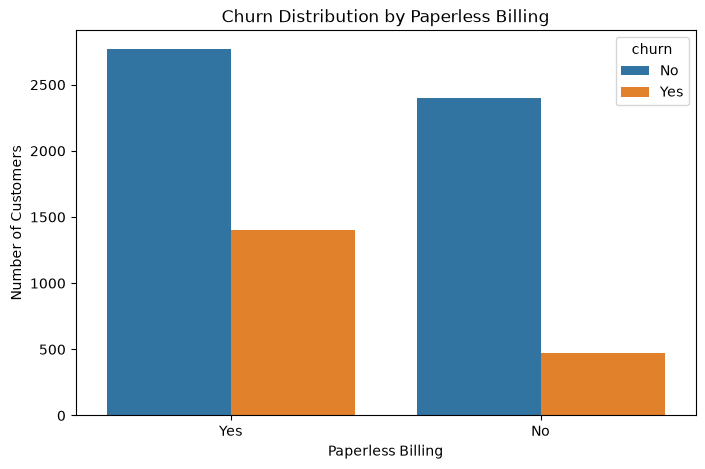

In [56]:
plt.figure(figsize=(8, 5))
sns.countplot(x='paperlessbilling', hue='churn', data=df)
plt.title('Churn Distribution by Paperless Billing')
plt.xlabel('Paperless Billing')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers based on paperless billing status. This helps identify whether the use of paperless billing is associated with differences in customer churn.

### Observation

- Among customers who do not use paperless billing, 469 customers churned while 2,403 customers did not churn.

- Among customers who use paperless billing, 1,400 customers churned while 2,771 customers did not churn.

- The churn rate is approximately 16.3% for customers who do not use paperless billing and 33.6% for customers who use paperless billing.

- This indicates that customers who use paperless billing have a higher churn rate than customers who do not use paperless billing.

In [57]:
pd.crosstab(df['phoneservice'], df['churn'])

churn,No,Yes
phoneservice,,
No,512,170
Yes,4662,1699


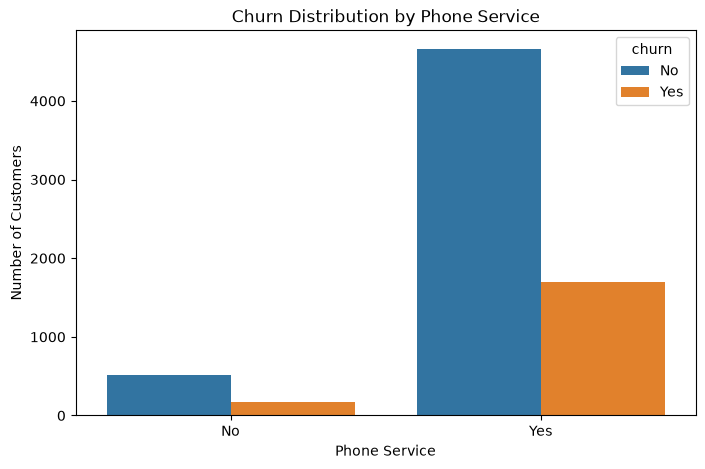

In [58]:
plt.figure(figsize=(8, 5))
sns.countplot(x='phoneservice', hue='churn', data=df)
plt.title('Churn Distribution by Phone Service')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers based on phone service status. This helps identify whether having phone service is associated with differences in customer churn.

### Observation

- Among customers without phone service, 170 customers churned while 512 customers did not churn.

- Among customers with phone service, 1,699 customers churned while 4,662 customers did not churn.

- The churn rate is approximately 24.9% for customers without phone service and 26.7% for customers with phone service.

- The churn rates are relatively close, although customers with phone service show a slightly higher churn rate.

- This indicates that phone service status does not show a large difference in churn rate compared with some of the other customer service features analyzed.

In [59]:
pd.crosstab(df['gender'], df['churn'])

churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


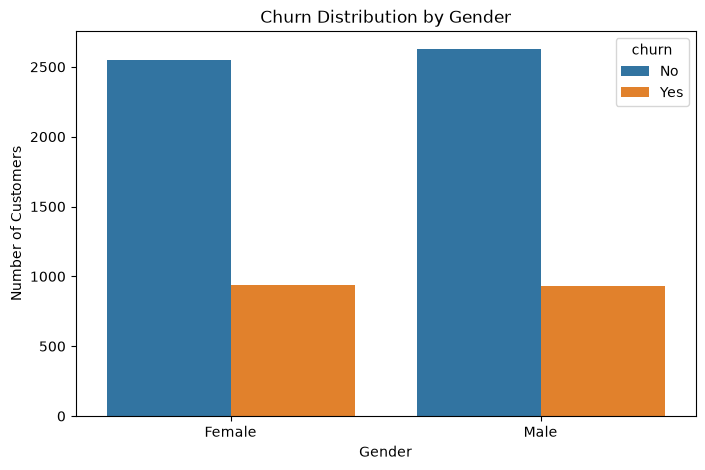

In [60]:
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', hue='churn', data=df)
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across gender categories. This helps identify whether customer churn differs between male and female customers.

### Observation

- Among female customers, 939 customers churned while 2,549 customers did not churn.

- Among male customers, 930 customers churned while 2,625 customers did not churn.

- The churn rate is approximately 26.9% for female customers and 26.2% for male customers.

- The churn rates are very similar between the two gender groups.

- This indicates that gender does not show a significant difference in customer churn in this dataset.

In [61]:
pd.crosstab(df['seniorcitizen'], df['churn'])

churn,No,Yes
seniorcitizen,,
0,4508,1393
1,666,476


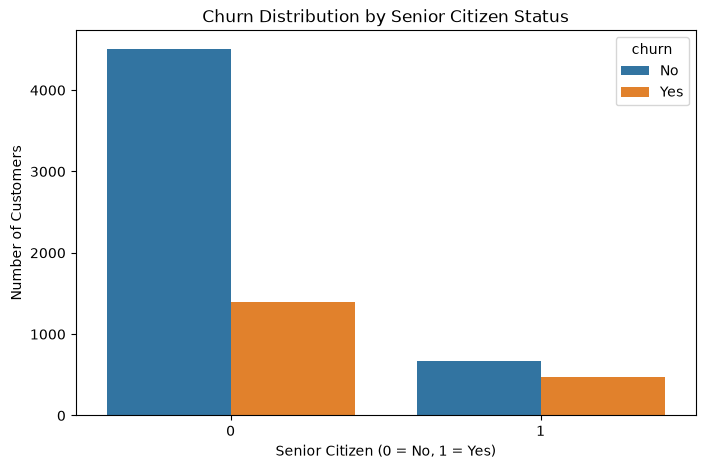

In [62]:
plt.figure(figsize=(8, 5))
sns.countplot(x='seniorcitizen', hue='churn', data=df)
plt.title('Churn Distribution by Senior Citizen Status')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers based on senior citizen status. This helps identify whether customer churn differs between senior and non-senior customers.

### Observation

- Among non-senior customers, 1,393 customers churned while 4,508 customers did not churn.

- Among senior customers, 476 customers churned while 666 customers did not churn.

- The churn rate is approximately 23.6% for non-senior customers and 41.7% for senior customers.

- This indicates that senior customers have a considerably higher churn rate than non-senior customers in this dataset.

In [63]:
pd.crosstab(df['multiplelines'], df['churn'])

churn,No,Yes
multiplelines,,
No,2541,849
No phone service,512,170
Yes,2121,850


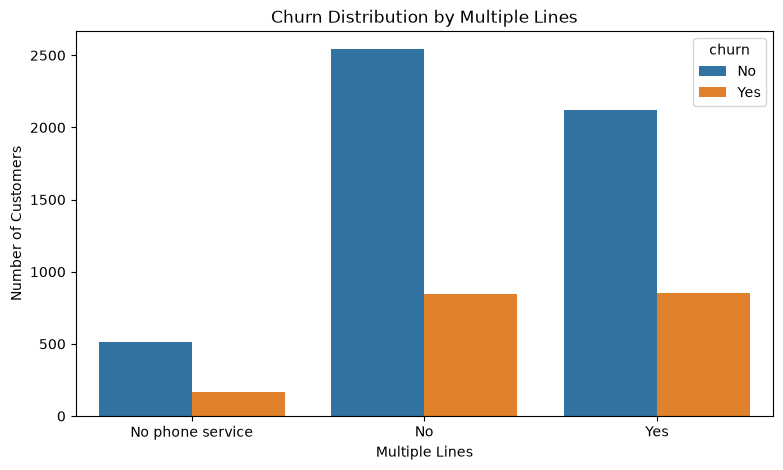

In [64]:
plt.figure(figsize=(9, 5))
sns.countplot(x='multiplelines', hue='churn', data=df)
plt.title('Churn Distribution by Multiple Lines')
plt.xlabel('Multiple Lines')
plt.ylabel('Number of Customers')
plt.show()

### Why This Plot Was Used

A count plot with churn as the hue was used to compare churn and non-churn customers across different multiple-line service categories. This helps identify whether having multiple phone lines is associated with differences in customer churn.

### Observation

- Among customers without multiple lines, 849 customers churned while 2,541 customers did not churn.

- Among customers with multiple lines, 850 customers churned while 2,121 customers did not churn.

- Among customers with no phone service, 170 customers churned while 512 customers did not churn.

- The churn rate is approximately 25.0% for customers without multiple lines, 28.6% for customers with multiple lines, and 24.9% for customers with no phone service.

- The churn rates across the three categories are relatively close, although customers with multiple lines show a slightly higher churn rate.

- This indicates that multiple-line status does not show a strong difference in churn compared with some of the other variables analyzed.

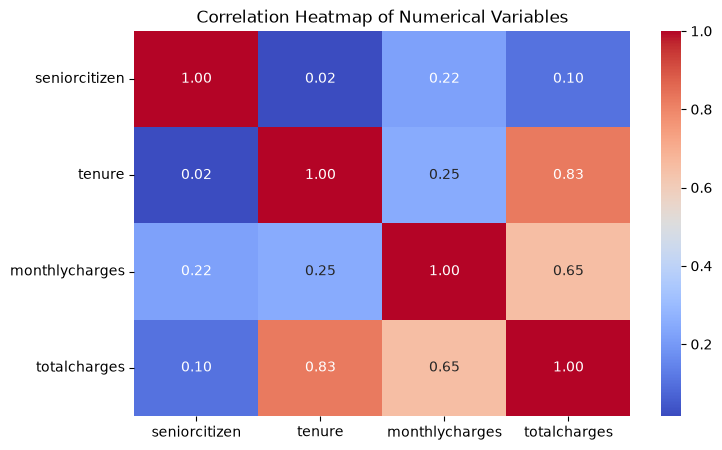

In [65]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Observation

- The correlation heatmap shows the strength of relationships among the numerical variables.

- The strongest positive correlation is between tenure and totalcharges, with a correlation coefficient of 0.83. This indicates that customers with longer tenure generally have higher total charges.

- Monthlycharges and totalcharges also show a moderately strong positive correlation of 0.65, indicating that customers with higher monthly charges tend to have higher total charges.

- The correlation between tenure and monthlycharges is relatively weak at 0.25.

- Seniorcitizen has relatively weak correlations with the other numerical variables, with the highest correlation being 0.22 with monthlycharges.

- Overall, tenure has the strongest relationship with totalcharges among the numerical variables.

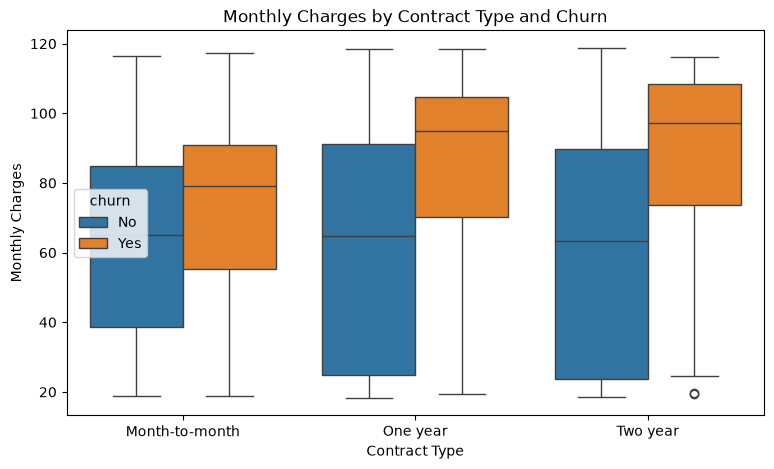

In [66]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='contract', y='monthlycharges', hue='churn', data=df)
plt.title('Monthly Charges by Contract Type and Churn')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.show()

### Why This Plot Was Used

A box plot was used to compare the distribution of monthly charges across different contract types while also separating customers by churn status. This helps examine how monthly charges and contract type together relate to customer churn.

### Observation

- The box plot shows that churned customers generally have higher monthly charges than non-churned customers across the different contract types.

- For month-to-month contracts, churned customers have a higher median monthly charge than customers who did not churn.

- For one-year and two-year contracts, the churned customers also tend to have higher monthly charges than non-churned customers.

- Overall, the combination of higher monthly charges and churn is more noticeable among churned customers. This suggests that monthly charges may be an important factor to consider along with contract type when analyzing customer churn.

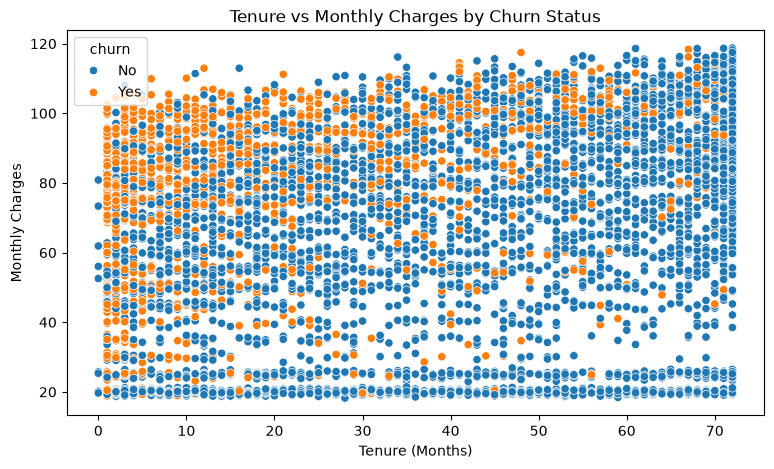

In [67]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x='tenure',
    y='monthlycharges',
    hue='churn',
    data=df
)
plt.title('Tenure vs Monthly Charges by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.show()

### Why This Plot Was Used

A scatter plot was used to examine the relationship between customer tenure and monthly charges while using churn status to distinguish between churned and non-churned customers. This helps identify patterns involving tenure, monthly charges, and churn simultaneously.

### Observation

- The scatter plot shows that customers with different tenure levels have a wide range of monthly charges.

- Churned customers are more visible among customers with relatively short tenure, particularly during the early months of the customer relationship.

- Customers with longer tenure are more frequently represented by non-churned customers.

- The plot also shows that monthly charges vary across all tenure levels, although higher monthly charges appear more frequently among churned customers.

- Overall, the visualization suggests that shorter tenure combined with higher monthly charges may be associated with a greater likelihood of churn.

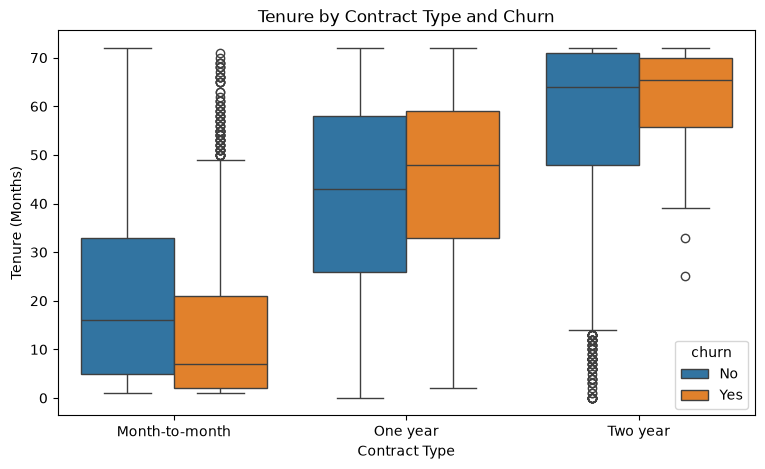

In [68]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='contract', y='tenure', hue='churn', data=df)
plt.title('Tenure by Contract Type and Churn')
plt.xlabel('Contract Type')
plt.ylabel('Tenure (Months)')
plt.show()

### Why This Plot Was Used

A box plot was used to compare customer tenure across different contract types while also separating customers by churn status. This helps examine how contract type and customer tenure together are associated with churn.

### Observation

- The plot shows a clear difference in customer tenure across contract types.

- Month-to-month customers generally have shorter tenure, while one-year and two-year contract customers tend to have longer tenure.

- Within the month-to-month contract group, churned customers generally have shorter tenure than non-churned customers.

- For one-year and two-year contracts, customers generally have longer tenure, and the number of churned customers is much smaller than for month-to-month contracts.

- Overall, the analysis suggests that longer tenure and longer-term contracts are associated with lower customer churn, while newer customers with month-to-month contracts are more likely to churn.

In [69]:
pivot_contract_churn = pd.pivot_table(
    df,
    index='contract',
    columns='churn',
    values='customerid',
    aggfunc='count'
)

pivot_contract_churn

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


### Observation

- The pivot table shows that month-to-month contracts have the highest number of churned customers, with 1,655 churned customers.

- One-year contracts have 166 churned customers, while two-year contracts have only 48 churned customers.

- This shows that churn is substantially higher among month-to-month customers compared with customers on longer-term contracts.

- Overall, longer contract durations are associated with lower customer churn in this dataset.

In [70]:
pivot_internet_churn = pd.pivot_table(
    df,
    index='internetservice',
    columns='churn',
    values='customerid',
    aggfunc='count'
)

pivot_internet_churn

churn,No,Yes
internetservice,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


### Observation

- The pivot table shows that Fiber optic customers have the highest number of churned customers, with 1,297 customers churning.

- DSL customers have 459 churned customers, while customers without internet service have only 113 churned customers.

- The churn rate is approximately 41.9% for Fiber optic customers, 19.0% for DSL customers, and 7.4% for customers without internet service.

- Overall, Fiber optic customers show the highest churn rate among the three internet service categories.

In [71]:
pivot_payment_churn = pd.pivot_table(
    df,
    index='paymentmethod',
    columns='churn',
    values='customerid',
    aggfunc='count'
)

pivot_payment_churn

churn,No,Yes
paymentmethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


### Observation

- The pivot table shows that electronic check customers have the highest number of churned customers, with 1,071 customers churning.

- Mailed check customers have 308 churned customers, while bank transfer and credit card customers have 258 and 232 churned customers respectively.

- The churn rate is approximately 45.3% for electronic check customers, 19.1% for mailed check customers, 16.7% for bank transfer customers, and 15.2% for credit card customers.

- Overall, customers using electronic check have a considerably higher churn rate than customers using the other payment methods.

## Key Business Insights

1. Month-to-month contract customers have the highest churn rate, while two-year contract customers have the lowest churn rate.

2. Fiber optic customers show a considerably higher churn rate than DSL and customers without internet service.

3. Customers with higher monthly charges generally show higher churn, indicating that pricing may be an important factor associated with customer churn.

4. Customers with shorter tenure are more likely to churn than customers with longer tenure.

5. Electronic check users have the highest churn rate among the payment methods.

6. Customers without online security, online backup, device protection, and technical support generally show higher churn rates than customers who have these services.

7. Customers without a partner or dependents have higher churn rates than customers with a partner or dependents.

8. Senior citizens show a higher churn rate than non-senior customers.

9. Gender and phone service show relatively small differences in churn rates compared with the stronger patterns observed for contract type, tenure, internet service, and payment method.

10. The correlation analysis shows a strong positive relationship between tenure and totalcharges, with a correlation coefficient of 0.83.

## Conclusion

- The exploratory data analysis of the Telco Customer Churn dataset provided several important insights into customer churn.

- The analysis shows that month-to-month contract customers have the highest churn rate, while customers with longer-term contracts have substantially lower churn. Fiber optic customers also show a higher churn rate compared with DSL and customers without internet service.

- Customers with shorter tenure and higher monthly charges tend to show higher churn. Payment method is another important factor, with electronic check customers having the highest churn rate.

- Customers without services such as online security, online backup, device protection, and technical support generally show higher churn rates. Senior citizens, customers without partners, and customers without dependents also show higher churn rates.

- The correlation analysis showed a strong positive relationship between tenure and totalcharges. Overall, the analysis highlights contract type, tenure, monthly charges, internet service, payment method, and additional support services as important factors associated with customer churn.

- These findings can help a telecom company identify customer groups with higher churn risk and develop targeted customer retention strategies.